# Đánh giá mô hình với K-Fold Cross Validation & Stacking Ensemble
Notebook này thực hiện 5-Fold CV cho từng mô hình con (Base Models) và mô hình tổng (Stacking) để đánh giá độ ổn định, so sánh hiệu năng, và kiểm tra hiện tượng rò rỉ dữ liệu (Data Leakage).

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_validate, KFold, GroupKFold
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Import thư viện thành công!')

Import thư viện thành công!


In [40]:
# Load Dữ liệu đã tiền xử lý hoàn chỉnh
df = pd.read_csv('Agri_Data_Preprocessed.csv')
df.head()
TARGET = 'NDVI_Season_Mean'
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'Feature columns: {X.shape[1]} | Target: {TARGET}')

Feature columns: 30 | Target: NDVI_Season_Mean


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4608 entries, 0 to 4607
Data columns (total 31 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Avg_Salinity_Index                         4608 non-null   float64
 1   Rain_Temp_Ratio                            4608 non-null   float64
 2   Rainfall                                   4608 non-null   float64
 3   Wind_Mean                                  4608 non-null   float64
 4   Temp_Min                                   4608 non-null   float64
 5   Wind_Max                                   4608 non-null   float64
 6   Temp_Max                                   4608 non-null   float64
 7   District                                   4608 non-null   float64
 8   Clay                                       4608 non-null   float64
 9   LAI                                        4608 non-null   float64
 10  Nitrogen                

In [42]:
# Khai báo các mô hình Base và Meta
models = {
    'XGBoost': xgb.XGBRegressor(random_state=RANDOM_STATE, n_estimators=500, learning_rate=0.05, max_depth=6),
    'LightGBM': lgb.LGBMRegressor(random_state=RANDOM_STATE, n_estimators=500, learning_rate=0.05, max_depth=6, verbose=-1),
    'CatBoost': CatBoostRegressor(random_state=RANDOM_STATE, iterations=500, learning_rate=0.05, depth=6, verbose=0),
    'RandomForest': RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=200, max_depth=10)
}

# Khai báo Stacking
estimators = [(name, model) for name, model in models.items()]
models['Stacking (Ridge)'] = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(),
    cv=5,
    n_jobs=-1
)


In [43]:
# Cấu hình K-Fold và Metrics đánh giá
kf = GroupKFold(n_splits=5)
scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error',
    'rmse': 'neg_root_mean_squared_error'
}

results_list = []

print("Bắt đầu 5-Fold Cross Validation cho từng mô hình...")
for name, model in models.items():
    print(f"Đang chạy CV cho {name}...")
    # Dùng n_jobs=1 hoặc n_jobs=-1 (nếu chạy local có nhiều core) để tăng tốc độ
    cv_results = cross_validate(model, X, y, cv=kf, groups=y, scoring=scoring, return_train_score=True, n_jobs=1)
    
    results_list.append({
        'Model': name,
        'Train R2': np.mean(cv_results['train_r2']),
        'Val R2': np.mean(cv_results['test_r2']),
        'Val MAE': -np.mean(cv_results['test_mae']),
        'Val MSE': -np.mean(cv_results['test_mse']),
        'Val RMSE': -np.mean(cv_results['test_rmse'])
    })

results_df = pd.DataFrame(results_list)
display(results_df.round(4))

Bắt đầu 5-Fold Cross Validation cho từng mô hình...
Đang chạy CV cho XGBoost...
Đang chạy CV cho LightGBM...
Đang chạy CV cho CatBoost...
Đang chạy CV cho RandomForest...
Đang chạy CV cho Stacking (Ridge)...


,Model,Train R2,Val R2,Val MAE,Val MSE,Val RMSE
0,XGBoost,1.0000,0.8576,0.0278,0.0016,0.0400
1,LightGBM,1.0000,0.8289,0.0298,0.0020,0.0439
2,CatBoost,1.0000,0.8743,0.0267,0.0015,0.0377
3,RandomForest,1.0000,0.8497,0.0304,0.0018,0.0414
4,Stacking (Ridge),0.9946,0.8829,0.0264,0.0014,0.0363


In [47]:
# KIỂM TRA DATA LEAKAGE VÀ OVERFITTING
print("="*60)
print("BÁO CÁO KIỂM TRA DATA LEAKAGE VÀ OVERFITTING")
print("="*60)

for _, row in results_df.iterrows():
    model_name = row['Model']
    train_r2 = row['Train R2']
    val_r2 = row['Val R2']
    gap = train_r2 - val_r2
    
    print(f"\n[ {model_name} ]")
    print(f"  -> Train R2: {train_r2:.4f} | Validation R2: {val_r2:.4f} | Chênh lệch: {gap:.4f}")
print("\n" + "="*60)

BÁO CÁO KIỂM TRA DATA LEAKAGE VÀ OVERFITTING

[ XGBoost ]
  -> Train R2: 1.0000 | Validation R2: 0.8576 | Chênh lệch: 0.1424

[ LightGBM ]
  -> Train R2: 1.0000 | Validation R2: 0.8289 | Chênh lệch: 0.1711

[ CatBoost ]
  -> Train R2: 1.0000 | Validation R2: 0.8743 | Chênh lệch: 0.1257

[ RandomForest ]
  -> Train R2: 1.0000 | Validation R2: 0.8497 | Chênh lệch: 0.1503

[ Stacking (Ridge) ]
  -> Train R2: 0.9946 | Validation R2: 0.8829 | Chênh lệch: 0.1117



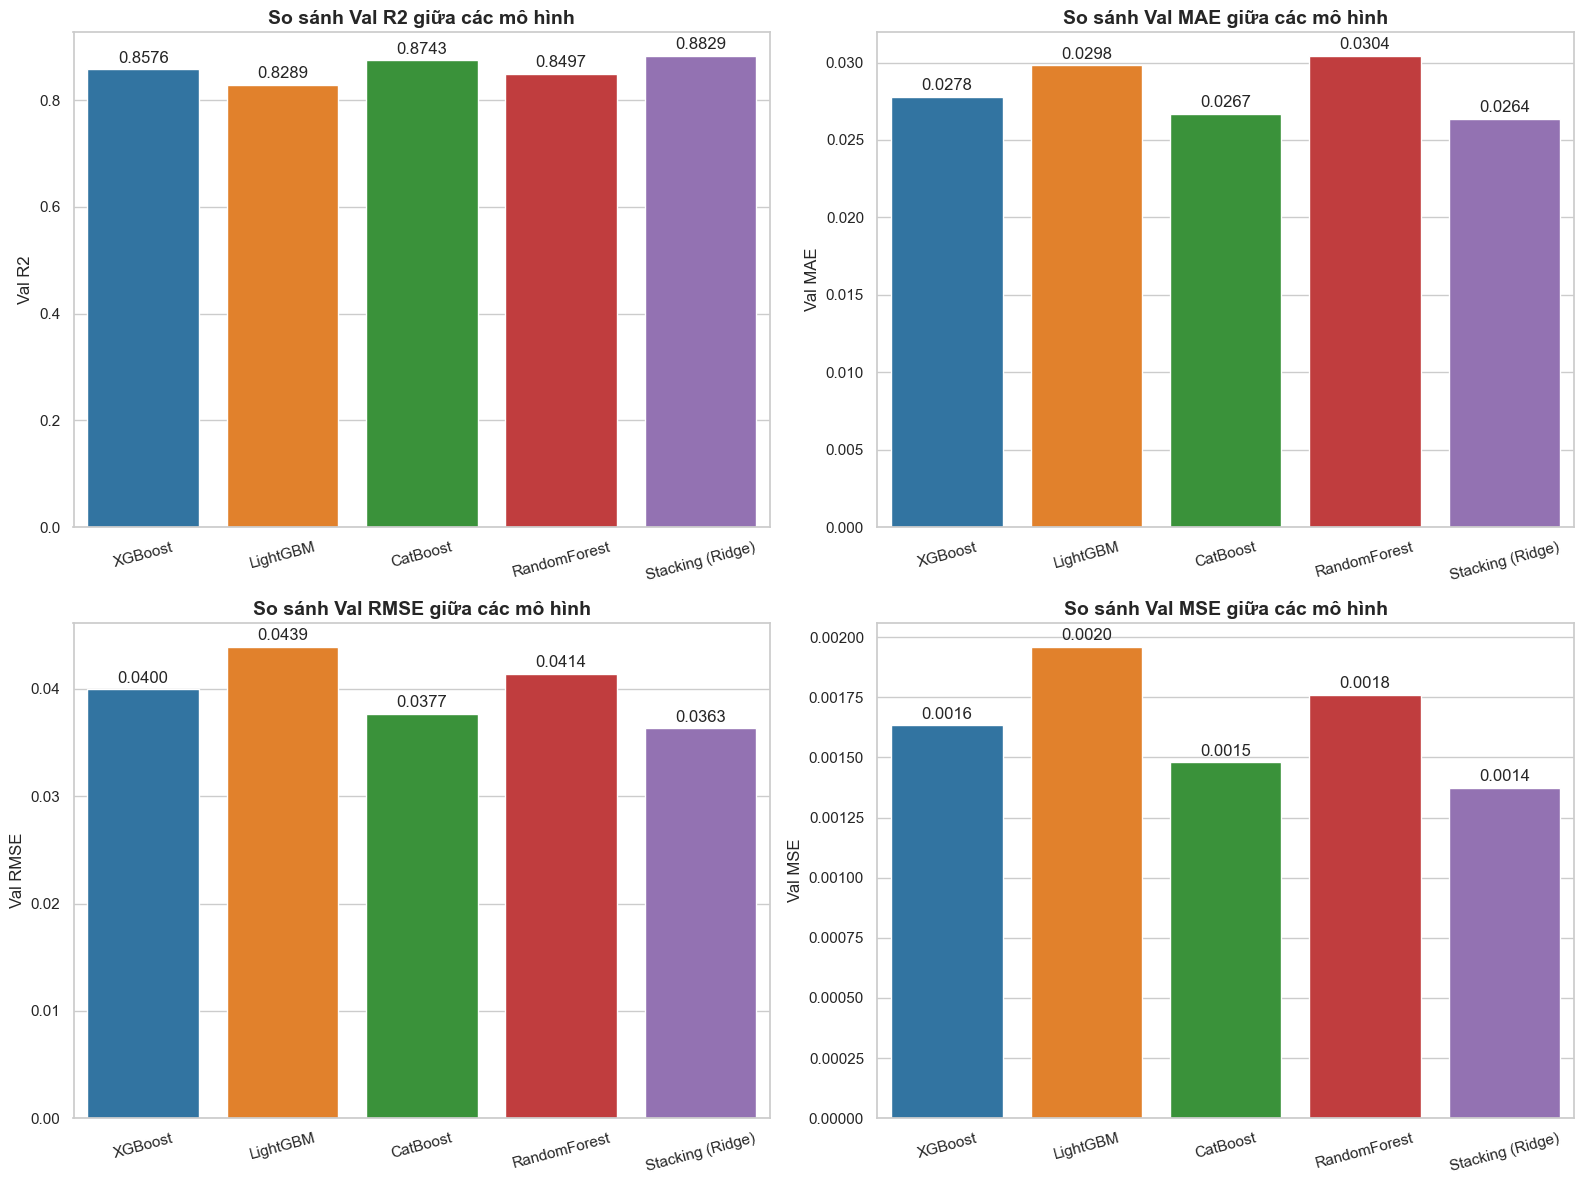

In [48]:
# VẼ BIỂU ĐỒ SO SÁNH 4 METRICS GIỮA CÁC MÔ HÌNH
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
metrics_to_plot = ['Val R2', 'Val MAE', 'Val RMSE', 'Val MSE']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'] # Màu cuối dành cho Stacking

for i, metric in enumerate(metrics_to_plot):
    row, col = divmod(i, 2)
    ax = axes[row, col]
    
    sns.barplot(x='Model', y=metric, data=results_df, ax=ax, palette=colors)
    ax.set_title(f'So sánh {metric} giữa các mô hình', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    
    # Thêm giá trị số lên đầu mỗi cột bar
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()